In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
pip show matplotlib

Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

## What is 'matplotlib'?

Let's look at a simple example of a scatterplot in 'matplotlib' using the 'iris' dataset, using the Axes interface: 

In [4]:
# Load in iris data
iris = pd.read_table("data/iris.txt", sep = ",")
iris.columns = ["sepal_length","sepal_width","petal_length","petal_width","species"]

We'll first create a **Figure**. It will have some properties (like a pixel resolution), but with no **Axes** there is nothing to display.

In [5]:
# An instatiated but empty figure
fig = plt.Figure()
fig

<Figure size 640x480 with 0 Axes>

Now we'll create a figure with one Axes.

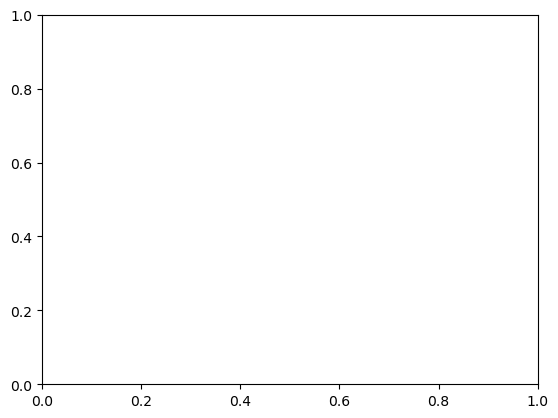

In [6]:
# Create empty figure with one Axes
fig, ax = plt.subplots()

plt.subplots takes **nrows** and **ncols** arguments, defining some grid of one or more plots. The defaults are 1 and 1 i.e. a single Axes representing one plot.

In [7]:
help(plt.subplots)

Help on function subplots in module matplotlib.pyplot:

subplots(
    nrows: 'int' = 1,
    ncols: 'int' = 1,
    *,
    sharex: "bool | Literal['none', 'all', 'row', 'col']" = False,
    sharey: "bool | Literal['none', 'all', 'row', 'col']" = False,
    squeeze: 'bool' = True,
    width_ratios: 'Sequence[float] | None' = None,
    height_ratios: 'Sequence[float] | None' = None,
    subplot_kw: 'dict[str, Any] | None' = None,
    gridspec_kw: 'dict[str, Any] | None' = None,
    **fig_kw
) -> 'tuple[Figure, Any]'
    Create a figure and a set of subplots.

    This utility wrapper makes it convenient to create common layouts of
    subplots, including the enclosing figure object, in a single call.

    Parameters
    ----------
    nrows, ncols : int, default: 1
        Number of rows/columns of the subplot grid.

    sharex, sharey : bool or {'none', 'all', 'row', 'col'}, default: False
        Controls sharing of properties among x (*sharex*) or y (*sharey*)
        axes:

        - T

We'll add **Axis's** and Artists to the Axes. 

When adding data to an Axes, the Axis's are created automatically based on attributes of the data. We can use matplotlib functions to further edit axis's we if want.

Artists are determined by the type of matplotlib plot you are creating. For example, if we use `plt.scatter`, the encoding will be points. 

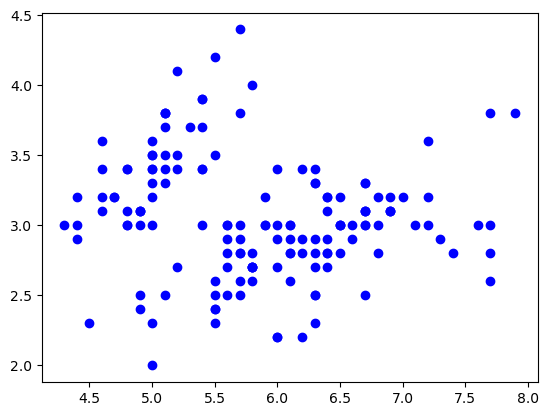

In [8]:
# Create empty Axes
fig, ax = plt.subplots()

# Plot observations from the first and second columns of the iris dataset as points on a scatterplot
ax.scatter(iris['sepal_length'], iris['sepal_width'], c = "blue");

Or using `plot` as a generic set of Axes and specifying the Artists as an argument. "o" indicates points and "b" indicates the color blue".

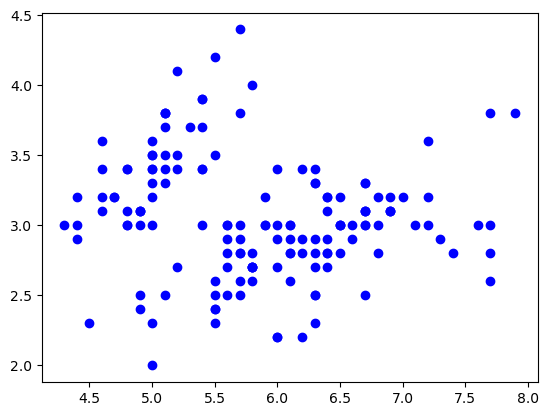

In [9]:
fig, ax = plt.subplots()
ax.plot(iris['sepal_length'], iris['sepal_width'], "ob");

Our data is now displayed on the previously empty plot. As you can see, 'matplotlib' automatically adjusted the axis ranges and tick labels to appropriately capture the full range of our two variables. Often such default behavior is fine, but these can always be further adjusted if not. 

With data drawn, lets now add some much needed context. We'll use the `set_xlabel`, `set_ylabel` and `set_title` methods to properly label our plot. 

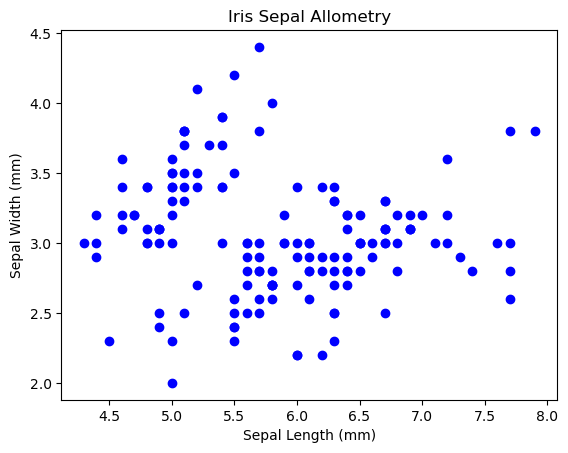

In [10]:
# Create empty figure
fig, ax = plt.subplots()

# Plot observations from the first and second columns of the iris dataset as points on a scatterplot
ax.scatter(x = iris['sepal_length'], y = iris['sepal_width'], c = "blue")

# Create plot labels
ax.set_xlabel("Sepal Length (mm)")
ax.set_ylabel("Sepal Width (mm)")
ax.set_title("Iris Sepal Allometry");

We could stop here and feel pretty good about our visualization, but lets just add a couple finishing touches. First, lets add gridlines to the background. This is primarily aesthetic preference, but gridlines can aid the comparison of values.

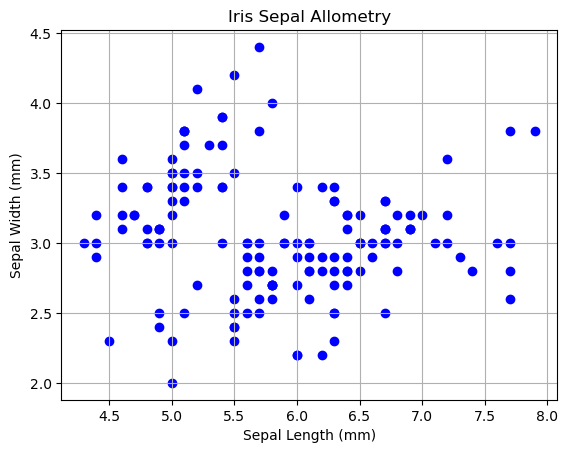

In [11]:
# Create empty figure
fig, ax = plt.subplots()

# Plot observations from the first and second columns of the iris dataset as points on a scatterplot
ax.scatter(x = iris['sepal_length'], y = iris['sepal_width'], c = "blue")

# Create plot labels
ax.set_xlabel("Sepal Length (mm)")
ax.set_ylabel("Sepal Width (mm)")
ax.set_title("Iris Sepal Allometry")

# Create gridlines
ax.grid(True);

Finally, lets make one final, minor adjustment. `tight_layout()` automatically adjusts padding in the plot margins to create more room for axis labels, which aren't automically considered when the plot is first initialized. This function becomes particularly relevant when plotting multiples subplots in the same figure, but also tends to adjust things nicely for single plots as well.  

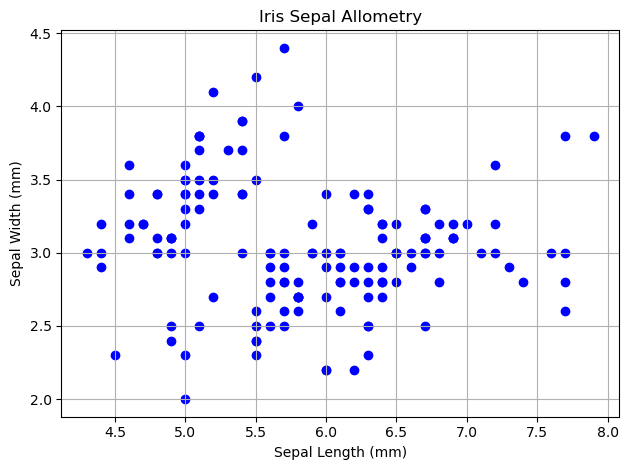

In [12]:
# Create empty figure
fig, ax = plt.subplots()

# Plot observations from the first and second columns of the iris dataset as points on a scatterplot
ax.scatter(x = iris['sepal_length'], y = iris['sepal_width'], c = "blue")

# Create plot labels
ax.set_xlabel("Sepal Length (mm)")
ax.set_ylabel("Sepal Width (mm)")
ax.set_title("Iris Sepal Allometry")

# Create gridlines
ax.grid(True)

# Tighten up the figure to fill its margins 
fig.tight_layout()

Possibly we don't like that the gridlines are painted over the points! Control the layering of Artists with `zorder`.

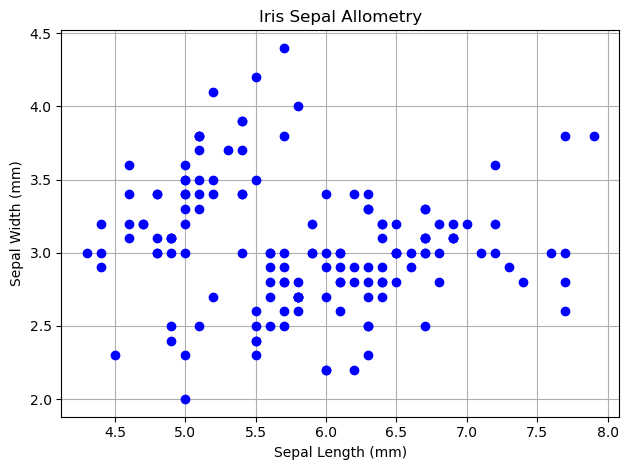

In [13]:
fig, ax = plt.subplots()

# Change the zorder of the scatter plot to be a layer "higher"
ax.scatter(x = iris['sepal_length'], y = iris['sepal_width'], c = "blue", zorder = 2)

ax.set_xlabel("Sepal Length (mm)")
ax.set_ylabel("Sepal Width (mm)")
ax.set_title("Iris Sepal Allometry")

# Place the grid one layer below the scatter artists
ax.grid(True, zorder = 1)

fig.tight_layout()

To do the same in the "pyplot" interface...

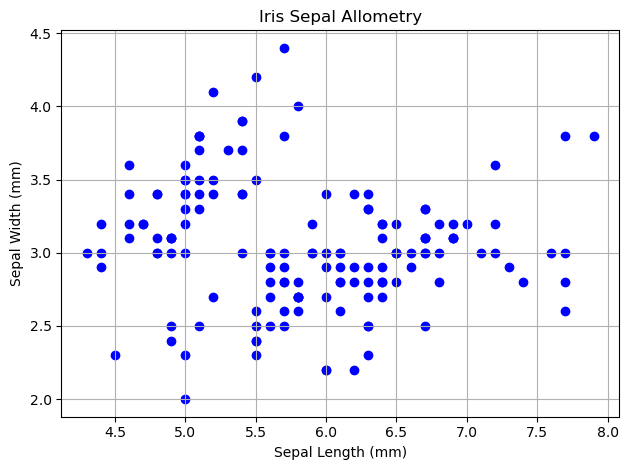

In [14]:
plt.scatter(x = iris['sepal_length'], y = iris['sepal_width'], c = "blue")

plt.xlabel("Sepal Length (mm)")
plt.ylabel("Sepal Width (mm)")
plt.title("Iris Sepal Allometry")
plt.grid()
plt.tight_layout()

In [15]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


We can plot more than one Axes on a single figure using `subplot`

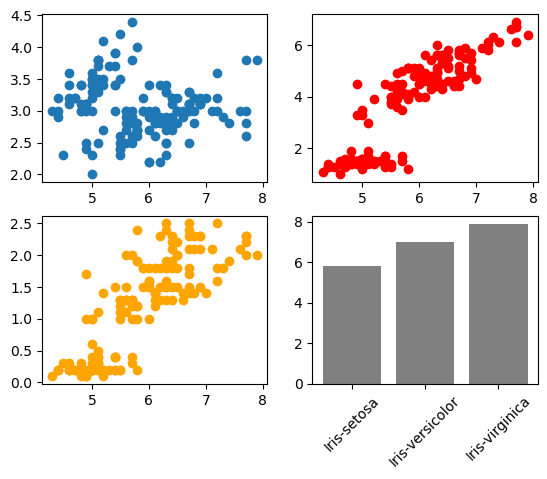

In [17]:
plt.subplot(2,2,1)
plt.scatter(iris['sepal_length'], iris['sepal_width'])
plt.subplot(2,2,2)
plt.scatter(iris['sepal_length'], iris['petal_length'], c = "red")
plt.subplot(2,2,3)
plt.scatter(iris['sepal_length'], iris['petal_width'], c = "orange")
plt.subplot(2,2,4)
plt.bar(iris['species'], iris['sepal_length'], color = "gray")
plt.xticks(rotation=45);

Or with Axes

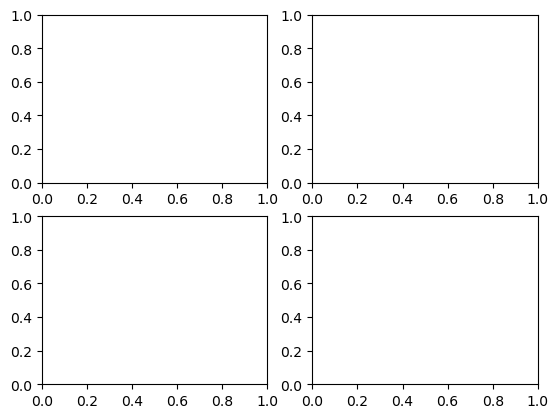

In [18]:
fig, ax = plt.subplots(2,2)

<BarContainer object of 149 artists>

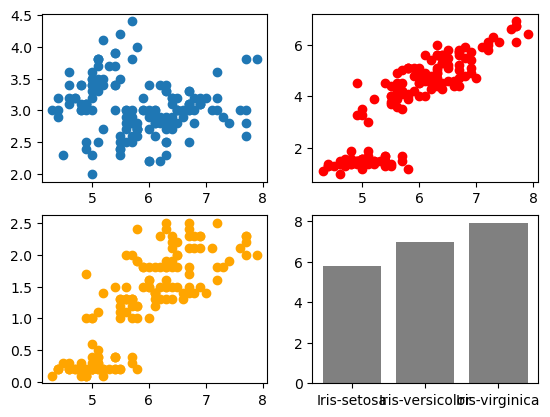

In [19]:
fig, ax = plt.subplots(2,2)
ax[0,0].scatter(iris['sepal_length'], iris['sepal_width'])
ax[0,1].scatter(iris['sepal_length'], iris['petal_length'], c = "red")
ax[1,0].scatter(iris['sepal_length'], iris['petal_width'], c = "orange")
ax[1,1].bar(iris['species'], iris['sepal_length'], color = "gray")